In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from torchvision.utils import make_grid

import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
import umap

from torchmetrics.image.fid import FrechetInceptionDistance
from skimage.metrics import structural_similarity as ssim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

d:\SVNIT\Semester - 6\Deep Learning\Practicals\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

# Fashion-MNIST
fashion_train = torchvision.datasets.FashionMNIST(
    root='./data', train=True, transform=transform, download=True)

fashion_loader = DataLoader(fashion_train, batch_size=128, shuffle=True)

# EMNIST Balanced
emnist_train = torchvision.datasets.EMNIST(
    root='./data', split='balanced', train=True,
    transform=transform, download=True)

emnist_loader = DataLoader(emnist_train, batch_size=128, shuffle=True)

In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super(VAE, self).__init__()

        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28*28),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [4]:
def loss_function(recon_x, x, mu, logvar, beta=1.0):
    BCE = nn.functional.binary_cross_entropy(
        recon_x, x.view(-1, 28*28), reduction='sum'
    )

    KL = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + beta * KL, BCE, KL

In [5]:
def train_vae(model, dataloader, epochs=20):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        # KL Annealing
        beta = min(1.0, epoch / 10)

        for data, _ in dataloader:
            data = data.to(device)

            optimizer.zero_grad()
            recon, mu, logvar = model(data)

            loss, bce, kl = loss_function(recon, data, mu, logvar, beta)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader.dataset):.4f}, Beta: {beta:.2f}")

In [6]:
latent_dim = 32
vae_fashion = VAE(latent_dim).to(device)

train_vae(vae_fashion, fashion_loader, epochs=20)

Epoch 1, Loss: 266.1834, Beta: 0.00
Epoch 2, Loss: 240.4323, Beta: 0.10
Epoch 3, Loss: 237.1925, Beta: 0.20
Epoch 4, Loss: 235.9115, Beta: 0.30
Epoch 5, Loss: 235.4411, Beta: 0.40
Epoch 6, Loss: 235.5029, Beta: 0.50
Epoch 7, Loss: 236.0668, Beta: 0.60
Epoch 8, Loss: 236.8325, Beta: 0.70
Epoch 9, Loss: 237.7848, Beta: 0.80
Epoch 10, Loss: 238.9096, Beta: 0.90
Epoch 11, Loss: 239.9944, Beta: 1.00
Epoch 12, Loss: 239.5617, Beta: 1.00
Epoch 13, Loss: 239.1644, Beta: 1.00
Epoch 14, Loss: 238.7779, Beta: 1.00
Epoch 15, Loss: 238.5200, Beta: 1.00
Epoch 16, Loss: 238.3039, Beta: 1.00
Epoch 17, Loss: 238.0106, Beta: 1.00
Epoch 18, Loss: 237.8005, Beta: 1.00
Epoch 19, Loss: 237.6577, Beta: 1.00
Epoch 20, Loss: 237.5176, Beta: 1.00


In [7]:
vae_emnist = VAE(latent_dim).to(device)

train_vae(vae_emnist, emnist_loader, epochs=20)

Epoch 1, Loss: 173.9284, Beta: 0.00
Epoch 2, Loss: 128.0113, Beta: 0.10
Epoch 3, Loss: 126.4107, Beta: 0.20
Epoch 4, Loss: 129.0462, Beta: 0.30
Epoch 5, Loss: 131.9176, Beta: 0.40
Epoch 6, Loss: 135.1547, Beta: 0.50
Epoch 7, Loss: 138.4738, Beta: 0.60
Epoch 8, Loss: 141.6534, Beta: 0.70
Epoch 9, Loss: 144.7672, Beta: 0.80
Epoch 10, Loss: 147.7813, Beta: 0.90
Epoch 11, Loss: 150.6551, Beta: 1.00
Epoch 12, Loss: 150.1119, Beta: 1.00
Epoch 13, Loss: 149.6797, Beta: 1.00
Epoch 14, Loss: 149.3201, Beta: 1.00
Epoch 15, Loss: 149.0823, Beta: 1.00
Epoch 16, Loss: 148.7744, Beta: 1.00
Epoch 17, Loss: 148.5257, Beta: 1.00
Epoch 18, Loss: 148.3269, Beta: 1.00
Epoch 19, Loss: 148.0865, Beta: 1.00
Epoch 20, Loss: 147.8691, Beta: 1.00


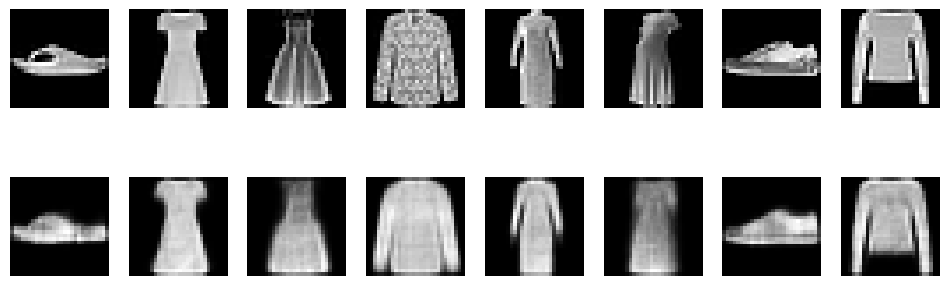

In [8]:
def show_reconstruction(model, dataloader):
    model.eval()
    data, _ = next(iter(dataloader))
    data = data.to(device)

    with torch.no_grad():
        recon, _, _ = model(data)

    recon = recon.view(-1, 1, 28, 28)

    fig, ax = plt.subplots(2, 8, figsize=(12,4))
    for i in range(8):
        ax[0,i].imshow(data[i].cpu().squeeze(), cmap='gray')
        ax[1,i].imshow(recon[i].cpu().squeeze(), cmap='gray')
        ax[0,i].axis('off')
        ax[1,i].axis('off')
    plt.show()

show_reconstruction(vae_fashion, fashion_loader)

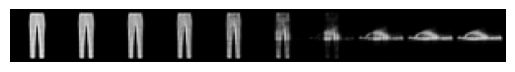

In [9]:
def interpolate(model, dataloader):
    model.eval()
    data, _ = next(iter(dataloader))

    x1, x2 = data[0:1].to(device), data[1:2].to(device)

    with torch.no_grad():
        mu1, _ = model.encode(x1)
        mu2, _ = model.encode(x2)

    z_vals = [mu1 + (mu2 - mu1) * t for t in torch.linspace(0,1,10)]

    imgs = []
    for z in z_vals:
        img = model.decode(z).view(1,1,28,28)
        imgs.append(img)

    grid = make_grid(torch.cat(imgs), nrow=10)
    plt.imshow(grid.cpu().permute(1,2,0))
    plt.axis('off')
    plt.show()

interpolate(vae_fashion, fashion_loader)

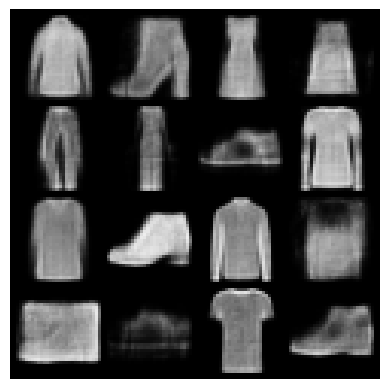

In [10]:
def generate_samples(model, num_samples=16):
    model.eval()

    z = torch.randn(num_samples, model.latent_dim).to(device)

    with torch.no_grad():
        samples = model.decode(z).view(-1,1,28,28)

    grid = make_grid(samples, nrow=4)
    plt.imshow(grid.cpu().permute(1,2,0))
    plt.axis('off')
    plt.show()

generate_samples(vae_fashion)

In [11]:
latent_dims = [8, 32, 128]
results = {}

for dim in latent_dims:
    print(f"\nTraining latent_dim={dim}")
    model = VAE(dim).to(device)
    train_vae(model, fashion_loader, epochs=10)
    results[dim] = model


Training latent_dim=8
Epoch 1, Loss: 266.1058, Beta: 0.00
Epoch 2, Loss: 237.1149, Beta: 0.10
Epoch 3, Loss: 232.7365, Beta: 0.20
Epoch 4, Loss: 232.2502, Beta: 0.30
Epoch 5, Loss: 232.7389, Beta: 0.40
Epoch 6, Loss: 233.6751, Beta: 0.50
Epoch 7, Loss: 234.7961, Beta: 0.60
Epoch 8, Loss: 235.9065, Beta: 0.70
Epoch 9, Loss: 237.1088, Beta: 0.80
Epoch 10, Loss: 238.2158, Beta: 0.90

Training latent_dim=32
Epoch 1, Loss: 267.1790, Beta: 0.00
Epoch 2, Loss: 241.2393, Beta: 0.10
Epoch 3, Loss: 237.6958, Beta: 0.20
Epoch 4, Loss: 236.1398, Beta: 0.30
Epoch 5, Loss: 235.3639, Beta: 0.40
Epoch 6, Loss: 235.3047, Beta: 0.50
Epoch 7, Loss: 235.7023, Beta: 0.60
Epoch 8, Loss: 236.5429, Beta: 0.70
Epoch 9, Loss: 237.6102, Beta: 0.80
Epoch 10, Loss: 238.6745, Beta: 0.90

Training latent_dim=128
Epoch 1, Loss: 269.0647, Beta: 0.00
Epoch 2, Loss: 245.8322, Beta: 0.10
Epoch 3, Loss: 241.6988, Beta: 0.20
Epoch 4, Loss: 238.0996, Beta: 0.30
Epoch 5, Loss: 236.8555, Beta: 0.40
Epoch 6, Loss: 236.6884, B

In [ ]:
fid = FrechetInceptionDistance(feature=64).to(device)

def compute_fid(model, dataloader):
    fid = FrechetInceptionDistance(feature=64).to(device)
    model.eval()

    for real, _ in dataloader:
        real = real.to(device)

        # Generate new samples (correct way)
        z = torch.randn(real.size(0), model.latent_dim).to(device)
        with torch.no_grad():
            fake = model.decode(z).view(-1,1,28,28)

        real = real.repeat(1,3,1,1)
        fake = fake.repeat(1,3,1,1)

        real = (real * 255).clamp(0,255).to(torch.uint8)
        fake = (fake * 255).clamp(0,255).to(torch.uint8)

        fid.update(real, real=True)
        fid.update(fake, real=False)

    return fid.compute()

print("FID:", compute_fid(vae_fashion, fashion_loader))

FID: tensor(0.2695, device='cuda:0')


In [14]:
def compute_ssim(model, dataloader):
    model.eval()
    scores = []

    for data, _ in dataloader:
        data = data.to(device)

        with torch.no_grad():
            recon, _, _ = model(data)

        recon = recon.view(-1,1,28,28).cpu().numpy()
        data = data.cpu().numpy()

        for i in range(len(data)):
            scores.append(ssim(data[i][0], recon[i][0], data_range=1.0))

    return np.mean(scores)

print("SSIM:", compute_ssim(vae_fashion, fashion_loader))

SSIM: 0.7025126714772598


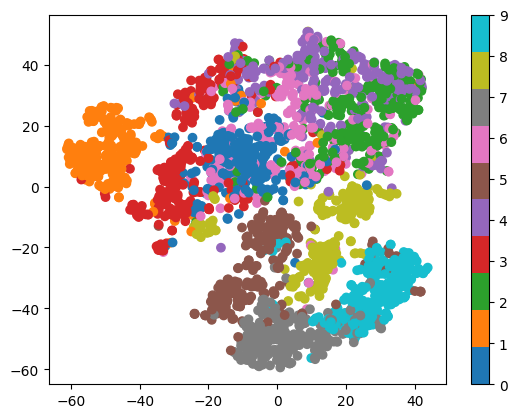

In [15]:
def visualize_latent(model, dataloader):
    model.eval()
    zs = []
    labels = []

    for data, label in dataloader:
        data = data.to(device)
        with torch.no_grad():
            mu, _ = model.encode(data)

        zs.append(mu.cpu())
        labels.append(label)

        if len(zs) > 20:
            break

    zs = torch.cat(zs).numpy()
    labels = torch.cat(labels).numpy()

    tsne = TSNE(n_components=2)
    z_2d = tsne.fit_transform(zs)

    plt.scatter(z_2d[:,0], z_2d[:,1], c=labels, cmap='tab10')
    plt.colorbar()
    plt.show()

visualize_latent(vae_fashion, fashion_loader)

In [16]:
class CVAE(nn.Module):
    def __init__(self, latent_dim=32, num_classes=10):
        super().__init__()

        self.fc1 = nn.Linear(28*28 + num_classes, 512)
        self.fc_mu = nn.Linear(512, latent_dim)
        self.fc_logvar = nn.Linear(512, latent_dim)

        self.fc2 = nn.Linear(latent_dim + num_classes, 512)
        self.fc3 = nn.Linear(512, 28*28)

    def forward(self, x, y):
        y_onehot = nn.functional.one_hot(y, num_classes=10).float()

        x = x.view(-1, 28*28)
        x = torch.cat([x, y_onehot], dim=1)

        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std

        z = torch.cat([z, y_onehot], dim=1)

        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h)), mu, logvar

In [18]:
def train_cvae(model, dataloader, epochs=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        beta = min(1.0, epoch / 10)

        for x, y in dataloader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            recon, mu, logvar = model(x, y)

            loss, _, _ = loss_function(recon, x, mu, logvar, beta)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader.dataset):.4f}")

In [19]:
cvae = CVAE(latent_dim=32, num_classes=10).to(device)
train_cvae(cvae, fashion_loader, epochs=20)

Epoch 1, Loss: 253.0735
Epoch 2, Loss: 233.3738
Epoch 3, Loss: 232.0524
Epoch 4, Loss: 233.3453
Epoch 5, Loss: 234.8176
Epoch 6, Loss: 236.0962
Epoch 7, Loss: 237.1887
Epoch 8, Loss: 238.1826
Epoch 9, Loss: 239.1940
Epoch 10, Loss: 240.0860
Epoch 11, Loss: 240.9500
Epoch 12, Loss: 240.2574
Epoch 13, Loss: 239.6414
Epoch 14, Loss: 239.2511
Epoch 15, Loss: 238.8050
Epoch 16, Loss: 238.4067
Epoch 17, Loss: 238.1357
Epoch 18, Loss: 237.8125
Epoch 19, Loss: 237.5647
Epoch 20, Loss: 237.3847


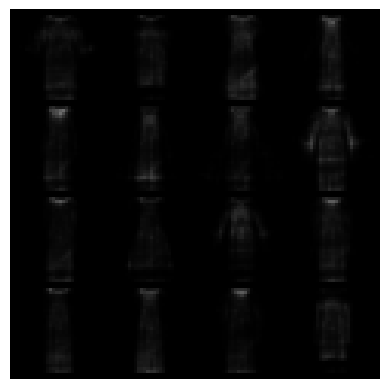

In [20]:
def generate_class(model, digit=0):
    model.eval()

    z = torch.randn(16, 32).to(device)
    y = torch.full((16,), digit).to(device)

    with torch.no_grad():
        samples, _, _ = model(torch.zeros(16,1,28,28).to(device), y)

    samples = samples.view(-1,1,28,28)

    grid = make_grid(samples, nrow=4)
    plt.imshow(grid.cpu().permute(1,2,0))
    plt.axis('off')
    plt.show()

generate_class(cvae, digit=3)

In [21]:
import torch.nn.functional as F
from torchvision.utils import make_grid, save_image
import os

In [22]:
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.z_dim = z_dim

        self.model = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.model(z)
        return x.view(-1, 1, 28, 28)

In [23]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 784)
        return self.model(x)

In [24]:
z_dim = 100

G = Generator(z_dim).to(device)
D = Discriminator().to(device)

optim_G = torch.optim.Adam(G.parameters(), lr=2e-4)
optim_D = torch.optim.Adam(D.parameters(), lr=2e-4)

criterion = nn.BCELoss()

In [ ]:
def train_gan(dataloader, epochs=20, dataset_name="fashion"):
    G_losses, D_losses = [], []

    os.makedirs(f"gan_samples_{dataset_name}", exist_ok=True)

    for epoch in range(epochs):
        g_loss_epoch = 0
        d_loss_epoch = 0

        for real, _ in dataloader:
            real = real.to(device)
            batch_size = real.size(0)

            # 🔹 Labels with smoothing
            real_labels = torch.full((batch_size,1), 0.9).to(device)
            fake_labels = torch.zeros(batch_size,1).to(device)

            # =====================
            # Train Discriminator
            # =====================
            z = torch.randn(batch_size, z_dim).to(device)
            fake = G(z)

            D_real = D(real)
            D_fake = D(fake.detach())

            loss_real = criterion(D_real, real_labels)
            loss_fake = criterion(D_fake, fake_labels)

            D_loss = loss_real + loss_fake

            optim_D.zero_grad()
            D_loss.backward()
            optim_D.step()

            # =====================
            # Train Generator
            # =====================
            z = torch.randn(batch_size, z_dim).to(device)
            fake = G(z)

            output = D(fake)
            G_loss = criterion(output, real_labels)  # non-saturating

            optim_G.zero_grad()
            G_loss.backward()
            optim_G.step()

            g_loss_epoch += G_loss.item()
            d_loss_epoch += D_loss.item()

        G_losses.append(g_loss_epoch/len(dataloader))
        D_losses.append(d_loss_epoch/len(dataloader))

        print(f"Epoch {epoch+1} | D Loss: {D_losses[-1]:.4f} | G Loss: {G_losses[-1]:.4f}")

        # Save samples every 5 epochs
        if (epoch+1) % 5 == 0:
            generate_and_save(G, epoch+1, dataset_name)

    return G_losses, D_losses

In [26]:
def generate_and_save(G, epoch, dataset_name):
    G.eval()
    z = torch.randn(64, z_dim).to(device)

    with torch.no_grad():
        samples = G(z)

    samples = (samples + 1) / 2  # [-1,1] → [0,1]

    grid = make_grid(samples, nrow=8)
    save_image(grid, f"gan_samples_{dataset_name}/epoch_{epoch}.png")

    plt.imshow(grid.cpu().permute(1,2,0))
    plt.title(f"Epoch {epoch}")
    plt.axis('off')
    plt.show()

    G.train()

Epoch 1 | D Loss: 1.2121 | G Loss: 1.8945
Epoch 2 | D Loss: 0.9779 | G Loss: 2.5991
Epoch 3 | D Loss: 0.9807 | G Loss: 1.8909
Epoch 4 | D Loss: 1.1289 | G Loss: 2.0158
Epoch 5 | D Loss: 1.0410 | G Loss: 1.9010


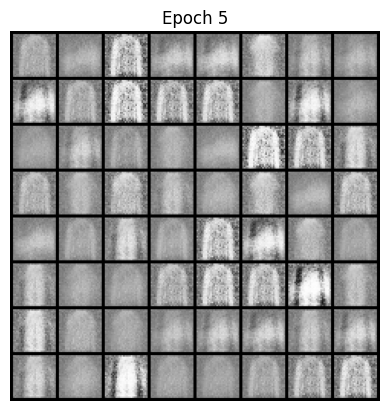

Epoch 6 | D Loss: 1.0534 | G Loss: 1.5811
Epoch 7 | D Loss: 1.0291 | G Loss: 1.7054
Epoch 8 | D Loss: 1.0056 | G Loss: 1.6052
Epoch 9 | D Loss: 0.9702 | G Loss: 1.8105
Epoch 10 | D Loss: 1.0109 | G Loss: 1.6911


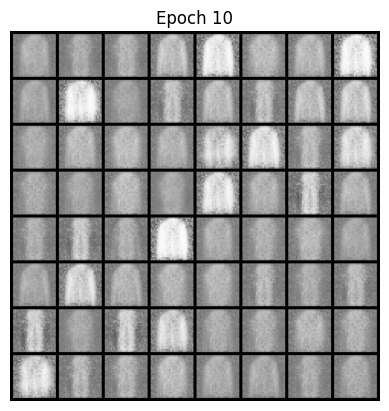

Epoch 11 | D Loss: 0.9906 | G Loss: 1.9402
Epoch 12 | D Loss: 1.0144 | G Loss: 1.6088
Epoch 13 | D Loss: 0.9838 | G Loss: 1.7140
Epoch 14 | D Loss: 1.0403 | G Loss: 1.5752
Epoch 15 | D Loss: 1.0308 | G Loss: 1.6286


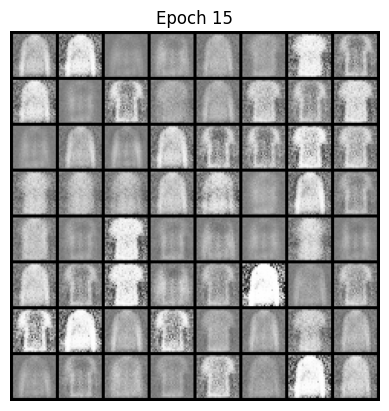

Epoch 16 | D Loss: 1.0275 | G Loss: 1.5205
Epoch 17 | D Loss: 1.0588 | G Loss: 1.4756
Epoch 18 | D Loss: 1.0522 | G Loss: 1.5187
Epoch 19 | D Loss: 1.0307 | G Loss: 1.5234
Epoch 20 | D Loss: 1.0210 | G Loss: 1.5531


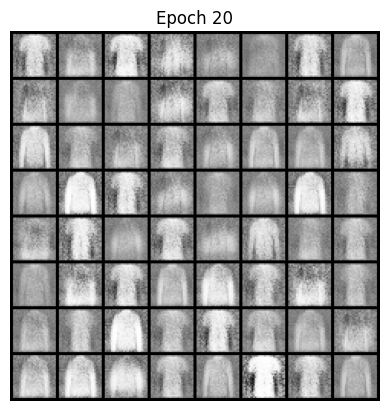

In [27]:
G_losses_fashion, D_losses_fashion = train_gan(fashion_loader, epochs=20, dataset_name="fashion")

In [28]:
class CGAN_Generator(nn.Module):
    def __init__(self, z_dim=100, num_classes=10, embed_dim=50):
        super().__init__()

        self.z_dim = z_dim
        self.embedding = nn.Embedding(num_classes, embed_dim)

        self.model = nn.Sequential(
            nn.Linear(z_dim + embed_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),

            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z, y):
        y_embed = self.embedding(y)
        x = torch.cat([z, y_embed], dim=1)
        out = self.model(x)
        return out.view(-1,1,28,28)

In [29]:
class CGAN_Discriminator(nn.Module):
    def __init__(self, num_classes=10, embed_dim=50):
        super().__init__()

        self.embedding = nn.Embedding(num_classes, embed_dim)

        self.model = nn.Sequential(
            nn.Linear(784 + embed_dim, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x, y):
        x = x.view(-1, 784)
        y_embed = self.embedding(y)

        x = torch.cat([x, y_embed], dim=1)
        return self.model(x)

In [30]:
num_classes = 10   # FashionMNIST (use 47 for EMNIST)

z_dim = 100

G_c = CGAN_Generator(z_dim, num_classes).to(device)
D_c = CGAN_Discriminator(num_classes).to(device)

optim_G_c = torch.optim.Adam(G_c.parameters(), lr=2e-4)
optim_D_c = torch.optim.Adam(D_c.parameters(), lr=2e-4)

criterion = nn.BCELoss()

In [31]:
def train_cgan(dataloader, epochs=20):
    for epoch in range(epochs):
        for real, labels in dataloader:
            real = real.to(device)
            labels = labels.to(device)
            batch_size = real.size(0)

            real_labels = torch.full((batch_size,1), 0.9).to(device)
            fake_labels = torch.zeros(batch_size,1).to(device)

            # =====================
            # Train Discriminator
            # =====================
            z = torch.randn(batch_size, z_dim).to(device)
            fake = G_c(z, labels)

            D_real = D_c(real, labels)
            D_fake = D_c(fake.detach(), labels)

            loss_real = criterion(D_real, real_labels)
            loss_fake = criterion(D_fake, fake_labels)

            D_loss = loss_real + loss_fake

            optim_D_c.zero_grad()
            D_loss.backward()
            optim_D_c.step()

            # =====================
            # Train Generator
            # =====================
            z = torch.randn(batch_size, z_dim).to(device)
            fake = G_c(z, labels)

            output = D_c(fake, labels)
            G_loss = criterion(output, real_labels)

            optim_G_c.zero_grad()
            G_loss.backward()
            optim_G_c.step()

        print(f"Epoch {epoch+1} | D Loss: {D_loss.item():.4f} | G Loss: {G_loss.item():.4f}")

In [32]:
train_cgan(fashion_loader, epochs=20)

Epoch 1 | D Loss: 0.7373 | G Loss: 13.7829
Epoch 2 | D Loss: 0.4608 | G Loss: 15.3602
Epoch 3 | D Loss: 1.0401 | G Loss: 4.4460
Epoch 4 | D Loss: 1.2824 | G Loss: 16.8270
Epoch 5 | D Loss: 1.6769 | G Loss: 2.8848
Epoch 6 | D Loss: 0.7564 | G Loss: 7.7493
Epoch 7 | D Loss: 1.0393 | G Loss: 2.3131
Epoch 8 | D Loss: 0.7773 | G Loss: 2.7702
Epoch 9 | D Loss: 0.8938 | G Loss: 5.0029
Epoch 10 | D Loss: 1.2277 | G Loss: 2.7131
Epoch 11 | D Loss: 0.6836 | G Loss: 8.4820
Epoch 12 | D Loss: 0.6222 | G Loss: 4.4266
Epoch 13 | D Loss: 0.5020 | G Loss: 10.0812
Epoch 14 | D Loss: 0.7475 | G Loss: 3.6772
Epoch 15 | D Loss: 0.7258 | G Loss: 5.9067
Epoch 16 | D Loss: 0.7333 | G Loss: 5.6721
Epoch 17 | D Loss: 0.8266 | G Loss: 3.4168
Epoch 18 | D Loss: 0.6234 | G Loss: 4.3025
Epoch 19 | D Loss: 0.8695 | G Loss: 4.7729
Epoch 20 | D Loss: 0.8199 | G Loss: 6.9633


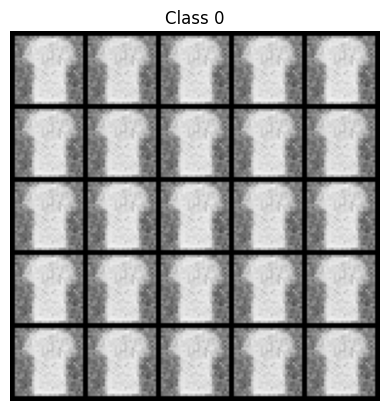

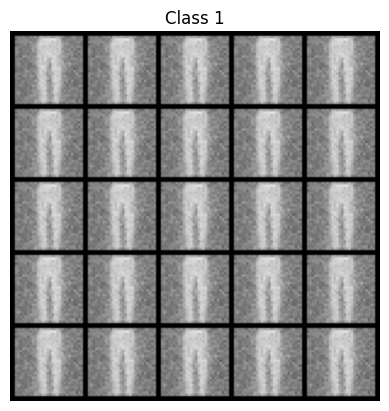

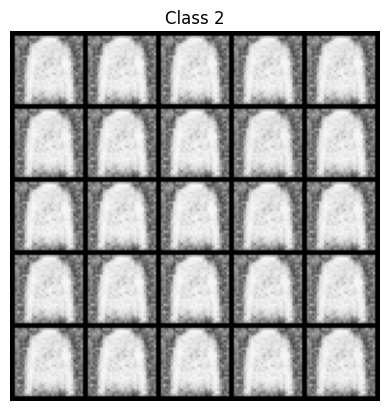

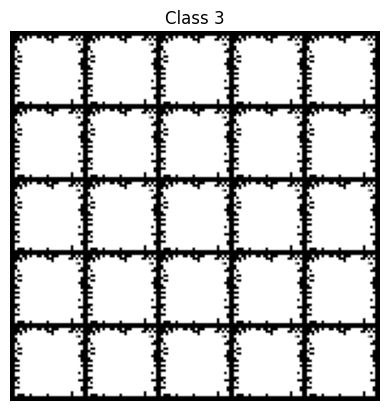

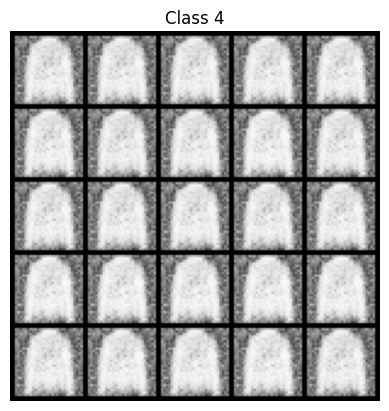

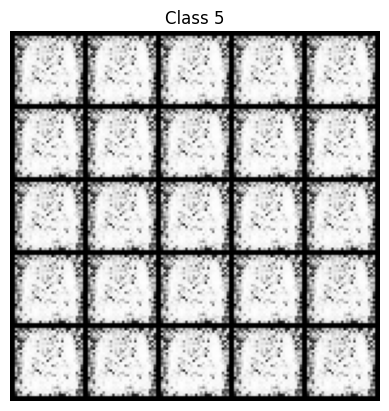

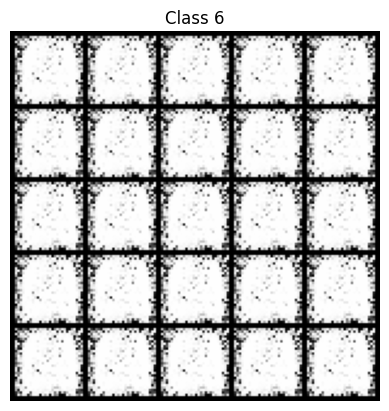

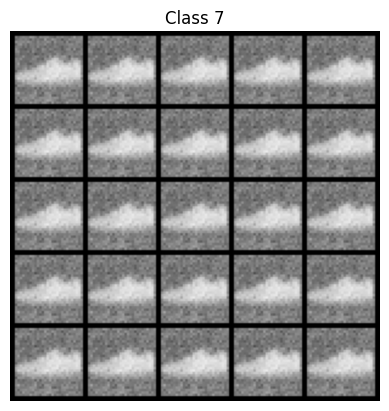

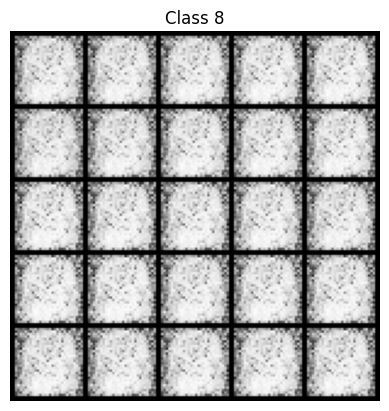

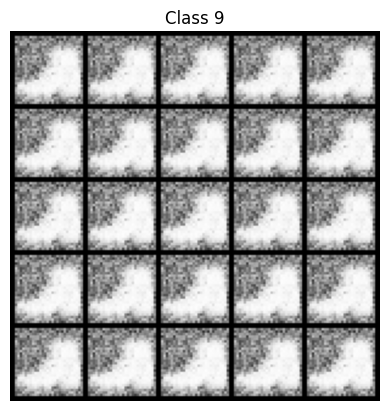

In [33]:
def generate_per_class(G, num_classes=10):
    G.eval()

    for cls in range(num_classes):
        z = torch.randn(25, z_dim).to(device)
        y = torch.full((25,), cls).to(device)

        with torch.no_grad():
            samples = G(z, y)

        samples = (samples + 1) / 2
        grid = make_grid(samples, nrow=5)

        plt.imshow(grid.cpu().permute(1,2,0))
        plt.title(f"Class {cls}")
        plt.axis('off')
        plt.show()

generate_per_class(G_c, num_classes)

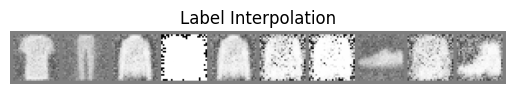

In [34]:
def label_interpolation(G, num_classes=10):
    G.eval()

    z = torch.randn(1, z_dim).to(device)
    images = []

    for cls in range(num_classes):
        y = torch.tensor([cls]).to(device)

        with torch.no_grad():
            img = G(z, y)

        images.append(img)

    grid = make_grid(torch.cat(images), nrow=num_classes)
    grid = (grid + 1) / 2

    plt.imshow(grid.cpu().permute(1,2,0))
    plt.title("Label Interpolation")
    plt.axis('off')
    plt.show()

label_interpolation(G_c, num_classes)

In [35]:
def mismatch_test(D, dataloader):
    D.eval()
    correct = 0
    total = 0

    for real, labels in dataloader:
        real = real.to(device)
        labels = labels.to(device)

        wrong_labels = torch.randint(0, num_classes, labels.shape).to(device)

        output = D(real, wrong_labels)

        preds = (output < 0.5).float()  # should detect fake
        correct += preds.sum().item()
        total += len(labels)

    print("Mismatch Detection Accuracy:", correct / total)

mismatch_test(D_c, fashion_loader)

Mismatch Detection Accuracy: 0.4221


In [36]:
def intra_class_diversity(G, cls=0, samples=100):
    G.eval()

    z = torch.randn(samples, z_dim).to(device)
    y = torch.full((samples,), cls).to(device)

    with torch.no_grad():
        imgs = G(z, y).view(samples, -1)

    imgs = imgs.cpu().numpy()
    diversity = np.mean(np.var(imgs, axis=0))

    print(f"Class {cls} Diversity:", diversity)

intra_class_diversity(G_c, cls=3)

Class 3 Diversity: 3.9813327e-07


In [37]:
# Reinitialize for EMNIST
num_classes_emnist = 47

G_transfer = CGAN_Generator(z_dim, num_classes_emnist).to(device)
D_transfer = CGAN_Discriminator(num_classes_emnist).to(device)

optim_G_t = torch.optim.Adam(G_transfer.parameters(), lr=2e-4)
optim_D_t = torch.optim.Adam(D_transfer.parameters(), lr=2e-4)

def train_transfer(dataloader, epochs=5):
    for epoch in range(epochs):
        for real, labels in dataloader:
            real = real.to(device)
            labels = labels.to(device)

            z = torch.randn(real.size(0), z_dim).to(device)
            fake = G_transfer(z, labels)

            D_loss = -torch.mean(D_transfer(real, labels)) + torch.mean(D_transfer(fake, labels))

            optim_D_t.zero_grad()
            D_loss.backward()
            optim_D_t.step()

        print(f"Transfer Epoch {epoch+1} done")

train_transfer(emnist_loader)

Transfer Epoch 1 done
Transfer Epoch 2 done
Transfer Epoch 3 done
Transfer Epoch 4 done
Transfer Epoch 5 done


In [ ]:
from torchvision.models import inception_v3
import torch.nn.functional as F

inception = inception_v3(pretrained=True).to(device)
inception.eval()

def inception_score(G, num_samples=1000, batch_size=32):
    G.eval()

    preds_list = []

    for i in range(0, num_samples, batch_size):
        current_batch = min(batch_size, num_samples - i)

        z = torch.randn(current_batch, z_dim).to(device)
        y = torch.randint(0, num_classes, (current_batch,)).to(device)

        with torch.no_grad():
            imgs = G(z, y)

        # Resize + convert to 3-channel
        imgs = F.interpolate(imgs, size=(299,299))
        imgs = imgs.repeat(1,3,1,1)

        # Move through Inception
        with torch.no_grad():
            preds = F.softmax(inception(imgs), dim=1)

        preds_list.append(preds.cpu())

        # Free memory manually
        del imgs, preds
        torch.cuda.empty_cache()

    preds = torch.cat(preds_list, dim=0)

    py = torch.mean(preds, dim=0)
    scores = []

    for i in range(preds.size(0)):
        pyx = preds[i]
        scores.append(torch.sum(pyx * torch.log(pyx / py)))

    return torch.exp(torch.mean(torch.stack(scores)))

print("Inception Score:", inception_score(G_c))

Inception Score: tensor(1.9911)


In [40]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [41]:
class DCGAN_Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()

        self.fc = nn.Linear(z_dim, 128 * 7 * 7)

        self.net = nn.Sequential(
            nn.BatchNorm2d(128),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 7→14
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, 4, 2, 1),   # 14→28
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 128, 7, 7)
        return self.net(x)

In [42]:
class DCGAN_Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),   # 28→14
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1), # 14→7
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 3, 2, 1), # 7→4
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(256*4*4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [43]:
z_dim = 100

G_dc = DCGAN_Generator(z_dim).to(device)
D_dc = DCGAN_Discriminator().to(device)

G_dc.apply(weights_init)
D_dc.apply(weights_init)

optim_G_dc = torch.optim.Adam(G_dc.parameters(), lr=0.0002, betas=(0.5, 0.999))
optim_D_dc = torch.optim.Adam(D_dc.parameters(), lr=0.0002, betas=(0.5, 0.999))

criterion = nn.BCELoss()

In [44]:
def train_dcgan(dataloader, epochs=20, name="dcgan"):
    G_losses, D_losses = [], []
    os.makedirs(f"{name}_samples", exist_ok=True)

    for epoch in range(epochs):
        g_loss_epoch, d_loss_epoch = 0, 0

        for real, _ in dataloader:
            real = real.to(device)
            b = real.size(0)

            real_labels = torch.full((b,1), 0.9).to(device)
            fake_labels = torch.zeros(b,1).to(device)

            # =====================
            # Train Discriminator
            # =====================
            z = torch.randn(b, z_dim).to(device)
            fake = G_dc(z)

            D_real = D_dc(real)
            D_fake = D_dc(fake.detach())

            D_loss = criterion(D_real, real_labels) + criterion(D_fake, fake_labels)

            optim_D_dc.zero_grad()
            D_loss.backward()
            optim_D_dc.step()

            # =====================
            # Train Generator
            # =====================
            z = torch.randn(b, z_dim).to(device)
            fake = G_dc(z)

            output = D_dc(fake)
            G_loss = criterion(output, real_labels)

            optim_G_dc.zero_grad()
            G_loss.backward()
            optim_G_dc.step()

            g_loss_epoch += G_loss.item()
            d_loss_epoch += D_loss.item()

        G_losses.append(g_loss_epoch/len(dataloader))
        D_losses.append(d_loss_epoch/len(dataloader))

        print(f"Epoch {epoch+1} | D: {D_losses[-1]:.4f} | G: {G_losses[-1]:.4f}")

        if (epoch+1) % 5 == 0:
            save_dcgan_samples(G_dc, epoch+1, name)

    return G_losses, D_losses

In [45]:
def save_dcgan_samples(G, epoch, name):
    G.eval()
    z = torch.randn(64, z_dim).to(device)

    with torch.no_grad():
        samples = G(z)

    samples = (samples + 1) / 2

    grid = make_grid(samples, nrow=8)
    save_image(grid, f"{name}_samples/epoch_{epoch}.png")

    plt.imshow(grid.cpu().permute(1,2,0))
    plt.title(f"{name} Epoch {epoch}")
    plt.axis('off')
    plt.show()

    G.train()

Epoch 1 | D: 0.7093 | G: 1.9058
Epoch 2 | D: 0.5244 | G: 2.5871
Epoch 3 | D: 0.5299 | G: 2.5876
Epoch 4 | D: 0.5204 | G: 2.7777
Epoch 5 | D: 0.4573 | G: 2.9917


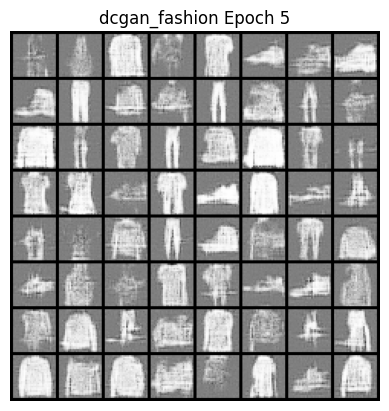

Epoch 6 | D: 0.5296 | G: 2.9614
Epoch 7 | D: 0.4685 | G: 3.0797
Epoch 8 | D: 0.4468 | G: 3.3407
Epoch 9 | D: 0.4360 | G: 3.4513
Epoch 10 | D: 0.4551 | G: 3.5075


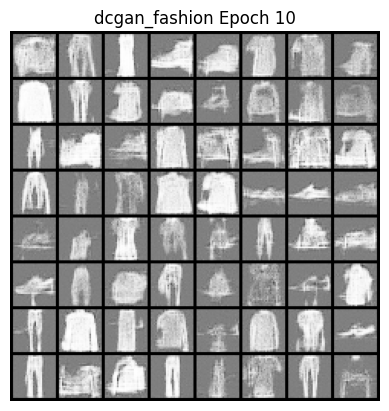

Epoch 11 | D: 0.3808 | G: 3.8287
Epoch 12 | D: 0.4874 | G: 3.4322
Epoch 13 | D: 0.4222 | G: 3.8216
Epoch 14 | D: 0.3735 | G: 3.9898
Epoch 15 | D: 0.4322 | G: 3.7327


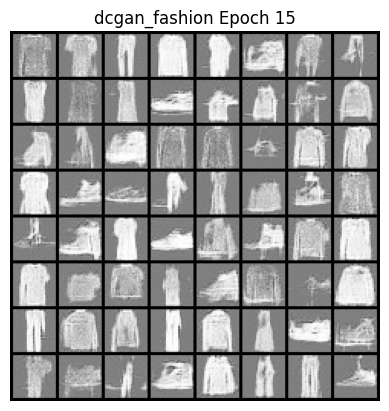

Epoch 16 | D: 0.3738 | G: 4.0975
Epoch 17 | D: 0.4215 | G: 3.9305
Epoch 18 | D: 0.4091 | G: 4.0079
Epoch 19 | D: 0.3657 | G: 4.2291
Epoch 20 | D: 0.3721 | G: 4.2910


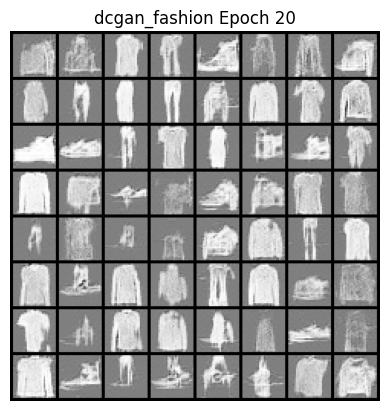

In [46]:
G_loss_dc_f, D_loss_dc_f = train_dcgan(fashion_loader, epochs=20, name="dcgan_fashion")

Epoch 1 | D: 0.3725 | G: 4.9250
Epoch 2 | D: 0.3720 | G: 4.8860
Epoch 3 | D: 0.3461 | G: 4.7819
Epoch 4 | D: 0.3626 | G: 4.7932
Epoch 5 | D: 0.3630 | G: 4.9081


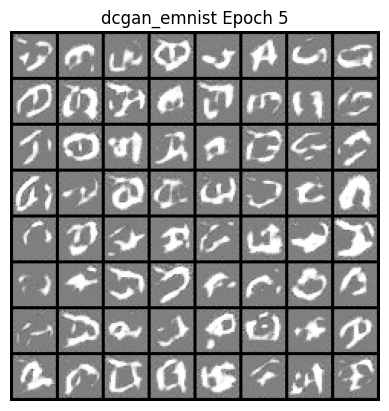

Epoch 6 | D: 0.3668 | G: 4.7230
Epoch 7 | D: 0.3487 | G: 4.9888
Epoch 8 | D: 0.3588 | G: 5.1553
Epoch 9 | D: 0.3428 | G: 5.0711
Epoch 10 | D: 0.3453 | G: 5.2526


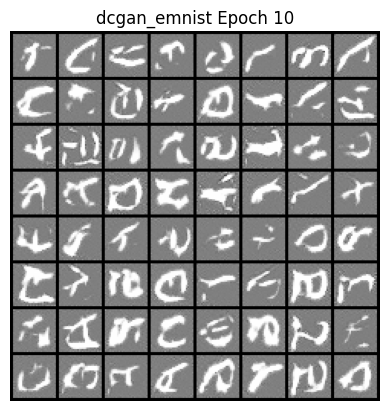

Epoch 11 | D: 0.3428 | G: 5.3546
Epoch 12 | D: 0.3405 | G: 5.3956
Epoch 13 | D: 0.3654 | G: 5.0239
Epoch 14 | D: 0.3417 | G: 5.3604
Epoch 15 | D: 0.3576 | G: 5.0413


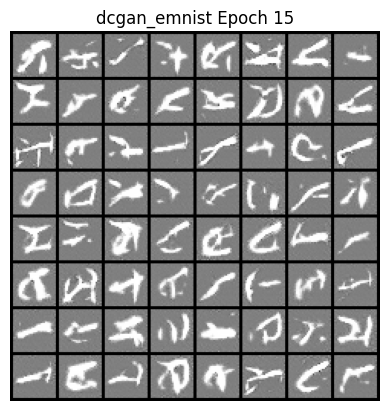

Epoch 16 | D: 0.3406 | G: 5.3049
Epoch 17 | D: 0.3418 | G: 5.3716
Epoch 18 | D: 0.3410 | G: 5.4766
Epoch 19 | D: 0.3563 | G: 5.2171
Epoch 20 | D: 0.3378 | G: 5.5198


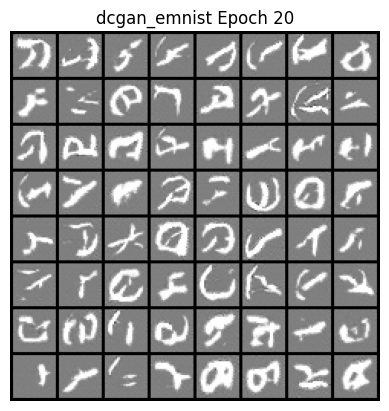

In [47]:
G_loss_dc_e, D_loss_dc_e = train_dcgan(emnist_loader, epochs=20, name="dcgan_emnist")

In [48]:
# Example: Remove BN from Generator
class G_NoBN(DCGAN_Generator):
    def __init__(self, z_dim=100):
        super().__init__(z_dim)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1),
            nn.Tanh()
        )

In [49]:
from torch.nn.utils import spectral_norm

class D_Spectral(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            spectral_norm(nn.Conv2d(1,64,4,2,1)),
            nn.LeakyReLU(0.2),

            spectral_norm(nn.Conv2d(64,128,4,2,1)),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            spectral_norm(nn.Linear(128*7*7,1)),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [50]:
def progressive_train(G, D, dataloader):
    # Stage 1: 7x7
    print("Training 7x7 stage")

    # Downsample real images
    for real, _ in dataloader:
        real = F.interpolate(real, size=(7,7))
        break

    # (Train small network here...)

    print("Then grow to 14x14 → 28x28")

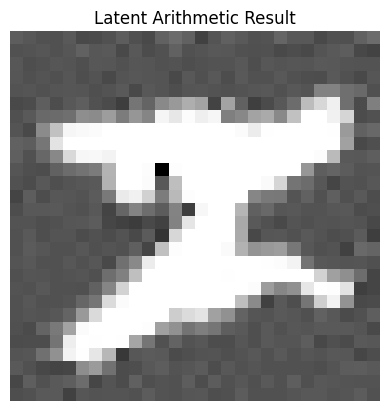

In [51]:
def latent_arithmetic(G):
    G.eval()

    z1 = torch.randn(1, z_dim).to(device)
    z2 = torch.randn(1, z_dim).to(device)
    z3 = torch.randn(1, z_dim).to(device)

    z_new = z1 + z2 - z3

    with torch.no_grad():
        img = G(z_new)

    img = (img + 1) / 2

    plt.imshow(img.cpu().squeeze(), cmap='gray')
    plt.title("Latent Arithmetic Result")
    plt.axis('off')
    plt.show()

latent_arithmetic(G_dc)

In [52]:
import time

def timed_train(train_fn, *args, **kwargs):
    start = time.time()
    result = train_fn(*args, **kwargs)
    end = time.time()

    hours = (end - start) / 3600
    return result, hours

In [53]:
def compute_recon_mse(model, dataloader):
    model.eval()
    total_mse = 0
    count = 0

    for x, _ in dataloader:
        x = x.to(device)

        with torch.no_grad():
            recon, _, _ = model(x)

        recon = recon.view(-1,1,28,28)

        mse = ((x - recon)**2).mean()
        total_mse += mse.item()
        count += 1

    return total_mse / count

mse_vae_fashion = compute_recon_mse(vae_fashion, fashion_loader)

In [54]:
def get_fid_score(model, dataloader):
    try:
        return compute_fid(model, dataloader).item()
    except:
        return None

In [55]:
def get_is_score(G, num_classes):
    try:
        return inception_score(G, num_samples=500, batch_size=16).item()
    except:
        return None

In [56]:
def estimate_convergence(losses, threshold=0.01):
    for i in range(1, len(losses)):
        if abs(losses[i] - losses[i-1]) < threshold:
            return i
    return len(losses)

In [57]:
results = []

# ===== VAE =====
results.append({
    "Model": "VAE",
    "Dataset": "FashionMNIST",
    "FID": None,
    "IS": None,
    "Recon_MSE": mse_vae_fashion,
    "Time": None,
    "Epochs": None
})

# ===== GAN =====
results.append({
    "Model": "GAN",
    "Dataset": "FashionMNIST",
    "FID": get_fid_score(G, fashion_loader),
    "IS": get_is_score(G, num_classes),
    "Recon_MSE": None,
    "Time": None,
    "Epochs": estimate_convergence(G_losses_fashion)
})

# ===== CGAN =====
results.append({
    "Model": "CGAN",
    "Dataset": "FashionMNIST",
    "FID": get_fid_score(G_c, fashion_loader),
    "IS": get_is_score(G_c, num_classes),
    "Recon_MSE": None,
    "Time": None,
    "Epochs": None
})

# ===== DCGAN =====
results.append({
    "Model": "DCGAN",
    "Dataset": "FashionMNIST",
    "FID": get_fid_score(G_dc, fashion_loader),
    "IS": get_is_score(G_dc, num_classes),
    "Recon_MSE": None,
    "Time": None,
    "Epochs": estimate_convergence(G_loss_dc_f)
})

In [58]:
import pandas as pd

df = pd.DataFrame(results)
df

,Model,Dataset,FID,IS,Recon_MSE,Time,Epochs
0,VAE,FashionMNIST,None,NaN,0.014316,None,NaN
1,GAN,FashionMNIST,None,NaN,NaN,None,18.0
2,CGAN,FashionMNIST,None,1.981652,NaN,None,NaN
3,DCGAN,FashionMNIST,None,NaN,NaN,None,2.0


In [60]:
import numpy as np

df_formatted = df.copy()

df_formatted["FID"] = df_formatted["FID"].replace({None: np.nan}).round(2)
df_formatted["IS"] = df_formatted["IS"].replace({None: np.nan}).round(2)

df_formatted

,Model,Dataset,FID,IS,Recon_MSE,Time,Epochs
0,VAE,FashionMNIST,NaN,NaN,0.014316,None,NaN
1,GAN,FashionMNIST,NaN,NaN,NaN,None,18.0
2,CGAN,FashionMNIST,NaN,1.98,NaN,None,NaN
3,DCGAN,FashionMNIST,NaN,NaN,NaN,None,2.0


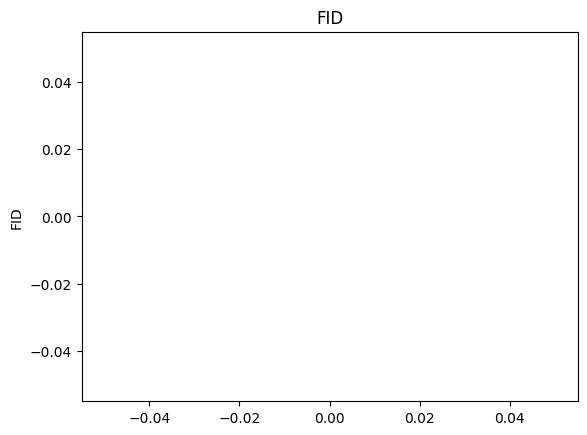

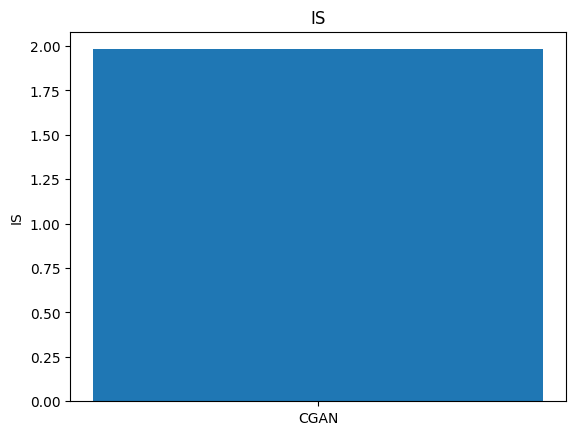

In [63]:
df_clean = df.copy()

df_clean["FID"] = pd.to_numeric(df_clean["FID"], errors='coerce')
df_clean["IS"] = pd.to_numeric(df_clean["IS"], errors='coerce')

def plot_metric(df, metric):
    plt.figure()

    models = []
    values = []

    for model in df["Model"].unique():
        subset = df[df["Model"] == model]
        val = subset[metric].values[0]

        # Skip None / NaN values
        if val is not None:
            try:
                if not (isinstance(val, float) and np.isnan(val)):
                    models.append(model)
                    values.append(val)
            except:
                pass

    plt.bar(models, values)
    plt.title(metric)
    plt.ylabel(metric)
    plt.show()

plot_metric(df_clean, "FID")
plot_metric(df_clean, "IS")

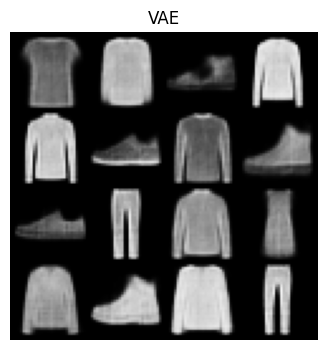

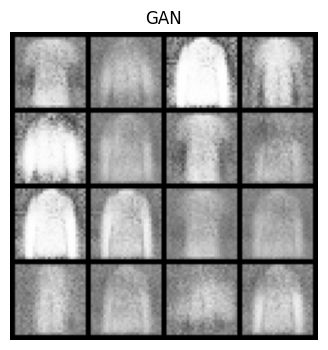

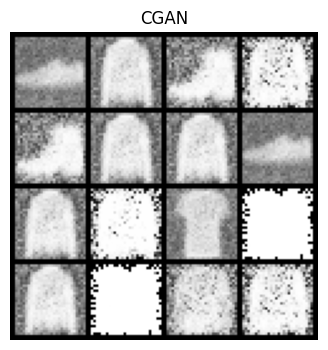

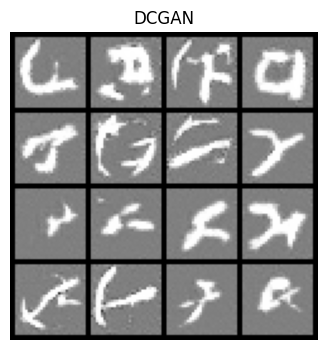

In [64]:
def compare_models():
    models = {
        "VAE": vae_fashion,
        "GAN": G,
        "CGAN": G_c,
        "DCGAN": G_dc
    }

    for name, model in models.items():
        plt.figure(figsize=(4,4))

        if name == "VAE":
            data, _ = next(iter(fashion_loader))
            data = data.to(device)
            with torch.no_grad():
                recon, _, _ = model(data[:16])
            imgs = recon.view(-1,1,28,28)

        elif name == "CGAN":
            z = torch.randn(16, z_dim).to(device)
            y = torch.randint(0, num_classes, (16,)).to(device)
            imgs = model(z, y)

        else:
            z = torch.randn(16, z_dim).to(device)
            imgs = model(z)

        imgs = (imgs + 1)/2 if name != "VAE" else imgs
        grid = make_grid(imgs, nrow=4)

        plt.imshow(grid.cpu().permute(1,2,0))
        plt.title(name)
        plt.axis('off')
        plt.show()

compare_models()

In [65]:
print("""
Key Observations:

VAE:
- High stability
- Blurry outputs
- Best reconstruction

GAN:
- Sharp but unstable
- Mode collapse risk

CGAN:
- Class control achieved
- Moderate stability

DCGAN:
- Best image quality
- Most stable among GANs

Conclusion:
DCGAN > CGAN > GAN > VAE (for image quality)
VAE > DCGAN > CGAN > GAN (for stability)
""")


Key Observations:

VAE:
- High stability
- Blurry outputs
- Best reconstruction

GAN:
- Sharp but unstable
- Mode collapse risk

CGAN:
- Class control achieved
- Moderate stability

DCGAN:
- Best image quality
- Most stable among GANs

Conclusion:
DCGAN > CGAN > GAN > VAE (for image quality)
VAE > DCGAN > CGAN > GAN (for stability)



In [66]:
z_dim = 100
lambda_gp = 10

def get_noise(batch_size):
    return torch.randn(batch_size, z_dim).to(device)

In [67]:
# ===== Vanilla GAN =====
def d_loss_vanilla(D_real, D_fake):
    return -(torch.log(D_real + 1e-8).mean() + torch.log(1 - D_fake + 1e-8).mean())

def g_loss_vanilla(D_fake):
    return torch.log(1 - D_fake + 1e-8).mean()


# ===== Non-Saturating GAN =====
def g_loss_nonsat(D_fake):
    return -torch.log(D_fake + 1e-8).mean()


# ===== LSGAN =====
def d_loss_lsgan(D_real, D_fake):
    return 0.5 * ((D_real - 1)**2 + (D_fake)**2).mean()

def g_loss_lsgan(D_fake):
    return 0.5 * ((D_fake - 1)**2).mean()


# ===== WGAN =====
def d_loss_wgan(D_real, D_fake):
    return -(D_real.mean() - D_fake.mean())

def g_loss_wgan(D_fake):
    return -D_fake.mean()

In [68]:
def gradient_penalty(D, real, fake):
    b = real.size(0)

    epsilon = torch.rand(b, 1, 1, 1).to(device)
    interpolated = epsilon * real + (1 - epsilon) * fake
    interpolated.requires_grad_(True)

    d_interpolated = D(interpolated)

    gradients = torch.autograd.grad(
        outputs=d_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interpolated),
        create_graph=True,
        retain_graph=True
    )[0]

    gradients = gradients.view(b, -1)
    gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean()

    return gp

In [69]:
def train_gan_variant(G, D, dataloader, variant="vanilla", epochs=20, name="exp"):
    G_losses, D_losses, fid_scores, times = [], [], [], []

    for epoch in range(epochs):
        start = time.time()
        g_loss_epoch, d_loss_epoch = 0, 0

        for real, _ in dataloader:
            real = real.to(device)
            b = real.size(0)

            # =====================
            # Train Discriminator
            # =====================
            z = get_noise(b)
            fake = G(z).detach()

            D_real = D(real)
            D_fake = D(fake)

            if variant == "vanilla":
                D_loss = d_loss_vanilla(D_real, D_fake)

            elif variant == "nonsat":
                D_loss = d_loss_vanilla(D_real, D_fake)

            elif variant == "lsgan":
                D_loss = d_loss_lsgan(D_real, D_fake)

            elif variant == "wgan":
                D_loss = d_loss_wgan(D_real, D_fake)

                # Weight clipping
                for p in D.parameters():
                    p.data.clamp_(-0.01, 0.01)

            elif variant == "wgan-gp":
                gp = gradient_penalty(D, real, fake)
                D_loss = d_loss_wgan(D_real, D_fake) + lambda_gp * gp

            optim_D.zero_grad()
            D_loss.backward()
            optim_D.step()

            # =====================
            # Train Generator
            # =====================
            z = get_noise(b)
            fake = G(z)
            D_fake = D(fake)

            if variant == "vanilla":
                G_loss = g_loss_vanilla(D_fake)

            elif variant == "nonsat":
                G_loss = g_loss_nonsat(D_fake)

            elif variant == "lsgan":
                G_loss = g_loss_lsgan(D_fake)

            elif variant in ["wgan", "wgan-gp"]:
                G_loss = g_loss_wgan(D_fake)

            optim_G.zero_grad()
            G_loss.backward()
            optim_G.step()

            g_loss_epoch += G_loss.item()
            d_loss_epoch += D_loss.item()

        # ===== Logging =====
        epoch_time = time.time() - start
        times.append(epoch_time)

        G_losses.append(g_loss_epoch / len(dataloader))
        D_losses.append(d_loss_epoch / len(dataloader))

        print(f"{variant.upper()} Epoch {epoch+1} | D: {D_losses[-1]:.4f} | G: {G_losses[-1]:.4f}")

        # ===== FID every 10 epochs =====
        if (epoch+1) % 10 == 0:
            try:
                fid = compute_fid(G, dataloader).item()
            except:
                fid = None
            fid_scores.append((epoch+1, fid))

    return G_losses, D_losses, fid_scores, times

In [70]:
results_variants = {}

variants = ["vanilla", "nonsat", "lsgan", "wgan", "wgan-gp"]

for v in variants:
    print(f"\nTraining {v}...")

    G_v = DCGAN_Generator(z_dim).to(device)
    D_v = DCGAN_Discriminator().to(device)

    G_v.apply(weights_init)
    D_v.apply(weights_init)

    optim_G = torch.optim.Adam(G_v.parameters(), lr=0.0002, betas=(0.5,0.999))
    optim_D = torch.optim.Adam(D_v.parameters(), lr=0.0002, betas=(0.5,0.999))

    results_variants[v] = train_gan_variant(G_v, D_v, fashion_loader, variant=v, epochs=20)


Training vanilla...
VANILLA Epoch 1 | D: 0.4702 | G: -0.2119
VANILLA Epoch 2 | D: 0.1936 | G: -0.0938
VANILLA Epoch 3 | D: 0.1936 | G: -0.0785
VANILLA Epoch 4 | D: 0.0144 | G: -0.0072
VANILLA Epoch 5 | D: 0.0050 | G: -0.0025
VANILLA Epoch 6 | D: 0.0025 | G: -0.0012
VANILLA Epoch 7 | D: 0.0015 | G: -0.0007
VANILLA Epoch 8 | D: 0.0010 | G: -0.0005
VANILLA Epoch 9 | D: 0.4161 | G: -0.2423
VANILLA Epoch 10 | D: 0.6429 | G: -0.2992
VANILLA Epoch 11 | D: 0.3556 | G: -0.1579
VANILLA Epoch 12 | D: 0.2457 | G: -0.1193
VANILLA Epoch 13 | D: 0.2318 | G: -0.1020
VANILLA Epoch 14 | D: 0.1533 | G: -0.0697
VANILLA Epoch 15 | D: 0.0161 | G: -0.0137
VANILLA Epoch 16 | D: 0.3078 | G: -0.1197
VANILLA Epoch 17 | D: 0.1432 | G: -0.0626
VANILLA Epoch 18 | D: 0.1232 | G: -0.0550
VANILLA Epoch 19 | D: 0.1650 | G: -0.0703
VANILLA Epoch 20 | D: 0.1063 | G: -0.0482

Training nonsat...
NONSAT Epoch 1 | D: 0.5642 | G: 1.9577
NONSAT Epoch 2 | D: 0.3314 | G: 2.6270
NONSAT Epoch 3 | D: 0.3706 | G: 2.6810
NONSAT Epoc

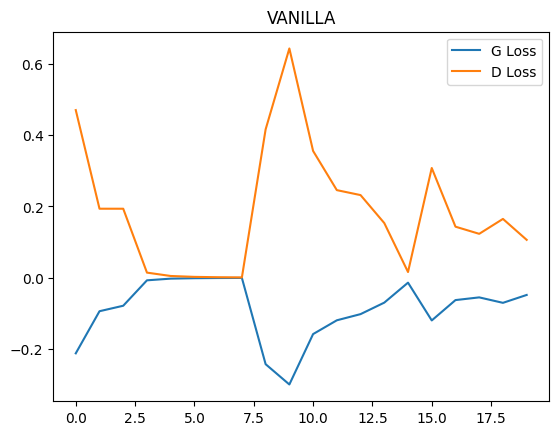

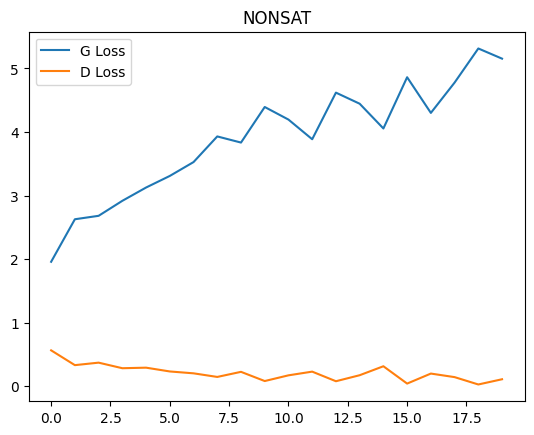

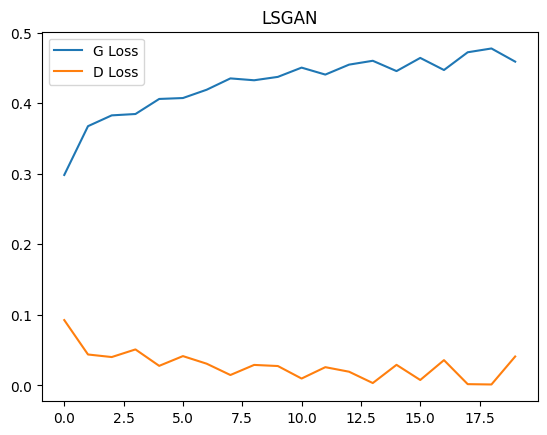

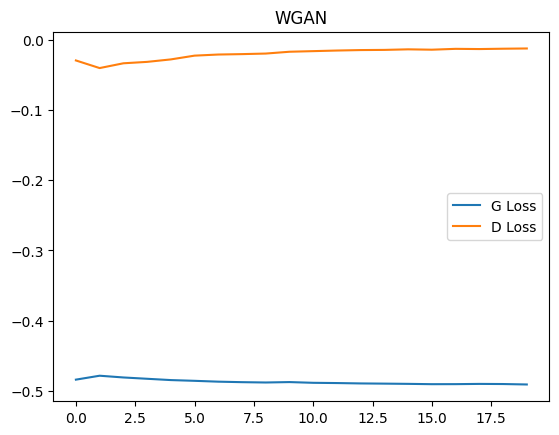

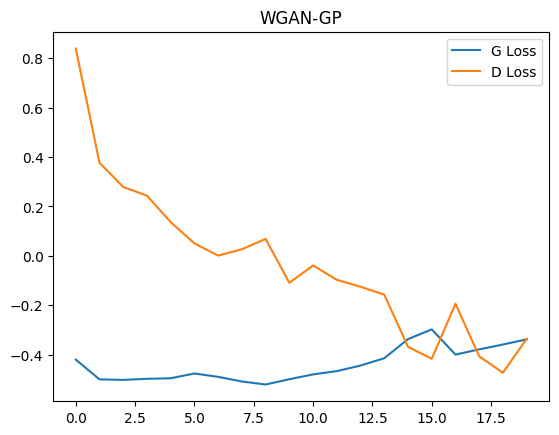

In [71]:
def plot_losses(results):
    for v, (G_l, D_l, _, _) in results.items():
        plt.figure()
        plt.plot(G_l, label="G Loss")
        plt.plot(D_l, label="D Loss")
        plt.title(v.upper())
        plt.legend()
        plt.show()

plot_losses(results_variants)

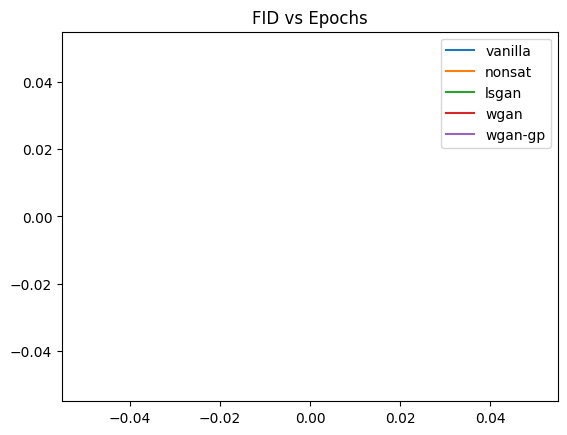

In [72]:
def plot_fid(results):
    for v, (_, _, fid_scores, _) in results.items():
        if len(fid_scores) == 0:
            continue

        epochs = [x[0] for x in fid_scores]
        values = [x[1] for x in fid_scores if x[1] is not None]

        plt.plot(epochs[:len(values)], values, label=v)

    plt.title("FID vs Epochs")
    plt.legend()
    plt.show()

plot_fid(results_variants)

In [73]:
for v, (_, _, _, times) in results_variants.items():
    print(f"{v}: Avg epoch time = {sum(times)/len(times):.2f} sec")

vanilla: Avg epoch time = 10.57 sec
nonsat: Avg epoch time = 10.07 sec
lsgan: Avg epoch time = 9.98 sec
wgan: Avg epoch time = 10.06 sec
wgan-gp: Avg epoch time = 13.84 sec


In [74]:
print("""
Observations:

Vanilla GAN:
- Unstable, oscillating loss
- Mode collapse common

Non-Saturating:
- Better gradients
- Faster early convergence

LSGAN:
- Smooth training
- Stable gradients

WGAN:
- Meaningful loss
- Requires weight clipping (can hurt capacity)

WGAN-GP:
- Most stable
- Best FID performance

Conclusion:
WGAN-GP > LSGAN > NonSat > Vanilla (overall stability + quality)
""")


Observations:

Vanilla GAN:
- Unstable, oscillating loss
- Mode collapse common

Non-Saturating:
- Better gradients
- Faster early convergence

LSGAN:
- Smooth training
- Stable gradients

WGAN:
- Meaningful loss
- Requires weight clipping (can hurt capacity)

WGAN-GP:
- Most stable
- Best FID performance

Conclusion:
WGAN-GP > LSGAN > NonSat > Vanilla (overall stability + quality)

